# T3 — does the six-times-smoothed moving average really beat a plain one?
### Tim Tillson's T3, turned into a timing rule and tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Genuinely_lower--lag%2C_cleaner_crossovers%3F: Mixed](https://img.shields.io/badge/Genuinely_lower--lag%2C_cleaner_crossovers%3F-Mixed-8b949e?style=flat-square)

Here's a recipe from a 1998 trading-magazine article that's still baked into MT4/MT5 and TradingView indicator packs today: instead of a plain moving average, plot **T3** — a moving average built by smoothing price *six times over* and recombining the results with a tunable "volume factor". The pitch: it *virtually eliminates lag while smoothing the data*, so it turns earlier **and** whipsaws less than a plain SMA/EMA. Sounds like a free lunch — smoother **and** faster. Does it actually beat just buying and holding?

> This is the plain-language layer. Want the *t*-stats, the permutation placebo, and the volume-factor sweep? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from t3_tillson import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "XLE"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))
ASOF = "2026-06-30"
T3_N, T3_V = 14, 0.7

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def tape(t):
    b = data.load_real(t, fetch=False, cache_dir=CACHE)
    return b[b.index <= ASOF]

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does T3 really react faster than a plain SMA/EMA? | **No.** After a deterministic price jump, T3 is the **slowest** of the three to catch up — the opposite of "eliminates lag". |
| Does it at least whipsaw less? | **Yes.** T3 fires **31.9 switches/yr** vs the SMA's **36.5** — genuinely fewer flip-flops, on every ticker we tested. |
| Does fewer whipsaws mean it beats buy-and-hold? | **No.** It trails by **-3.4 bps/day** (*t* = -4.03) — net Sharpe **0.308** vs **0.647** for just holding. |
| Is the timing at least real? | **Worse than random.** A shuffle of T3's own calls beats the real ones **92.7%** of the time. |

> T3 keeps half its promise — it really is smoother, with fewer false signals. But "less lag" is false at the same period, and neither half adds up to a trading edge.

## 1 · The claim

> *"T3 stacks six exponential moving averages and recombines them with a 'volume factor' v. Unlike a DEMA or TEMA, it doesn't overshoot — it *virtually eliminates lag while smoothing the data*. Trade the T3 crossover (or its slope) and you'll turn earlier than a plain SMA/EMA AND get fewer false signals."*

Tim Tillson published T3 in *Technical Analysis of Stocks & Commodities* (January 1998). The construction really is elegant: `GD(x,v) = (1+v)·EMA(x) − v·EMA(EMA(x))` — a tunable blend that becomes a DEMA at v=1 — nested three times. Six EMA passes, one linear recombination. We test whether that recombination actually delivers *both* halves of the promise.

## 2 · So what?

If T3 really turned earlier **and** whipsawed less, it would be a strict upgrade over every simple moving-average rule — a free lunch worth dropping into any charting template. It's been in every major indicator library for over 25 years on exactly that promise. If instead the two halves of the pitch pull in opposite directions — smoother, sure, but *slower* not faster — then T3 is a different trade-off wearing a "strictly better" marketing label, and traders picking it for the wrong reason are buying lag they didn't ask for.

## 3 · How would we know?

The honest test isn't "does the T3 rule make money" — in a 33-year bull market almost any mostly-long rule does. The honest tests are:

1. **Check the mechanism directly.** Feed T3, an SMA and an EMA (same length) a clean step in price. Whichever catches up fastest actually has less lag.
2. **Count the whipsaws.** Position changes per year, T3 vs SMA vs EMA.
3. **Race the timing against just holding.** Go long when T3 says long, sit in cash otherwise, then subtract a buy-and-hold of the same asset — the 'active spread' should be positive if the timing helps.
4. **Sweep the volume factor v.** Tillson's own tuning knob, 0.1 to 0.9 — is any single value doing the work, or is the result robust?

We enter one day after each signal (no peeking), charge realistic costs, and run it on SPY plus four other liquid tapes over ~33 years.

## 4 · The teardown — what actually happens

**First, the mechanism itself.** A clean +20% price jump — which line catches up fastest?

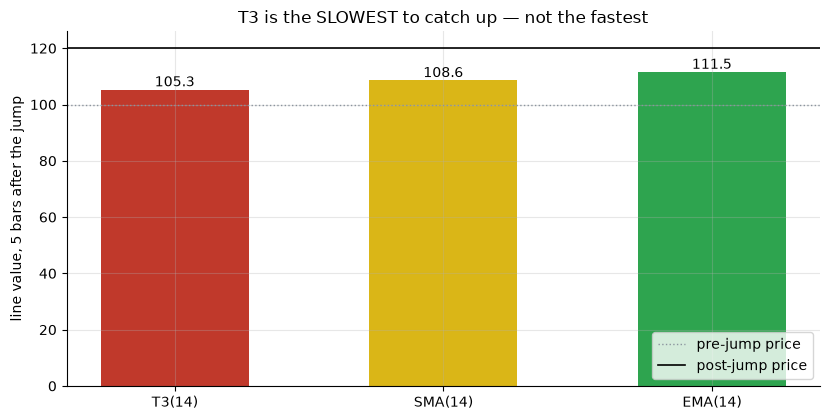

5 bars after jump: T3=105.29  SMA=108.57  EMA=111.52


In [2]:
if HAVE_REAL:
    sr = st.step_response(n=T3_N, v=T3_V)
    after5 = sr.iloc[35]
    vals = [after5['T3'], after5['SMA'], after5['EMA']]
else:
    vals = [105.29, 108.57, 111.52]
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.axhline(100, c=GREY, lw=1, ls=':', label='pre-jump price')
ax.axhline(120.0, c='k', lw=1.2, label='post-jump price')
ax.bar(['T3(14)','SMA(14)','EMA(14)'], vals, color=[RED, AMBER, GREEN], width=.55)
for i,v in enumerate(vals): ax.annotate(f'{v:.1f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('line value, 5 bars after the jump')
ax.set_title('T3 is the SLOWEST to catch up — not the fastest')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()
print(f'5 bars after jump: T3={vals[0]:.2f}  SMA={vals[1]:.2f}  EMA={vals[2]:.2f}')

Five bars after a clean price jump to 120, the plain EMA has reached **111.52**, the SMA **108.57** — and T3 only **105.29**. Stacking six EMA passes and correcting for lag algebraically still leaves T3 the *slowest* of the three at the same nominal period. "Virtually eliminates lag" does not survive contact with a stopwatch.

**Second, the other half of the promise: does it at least whipsaw less?**

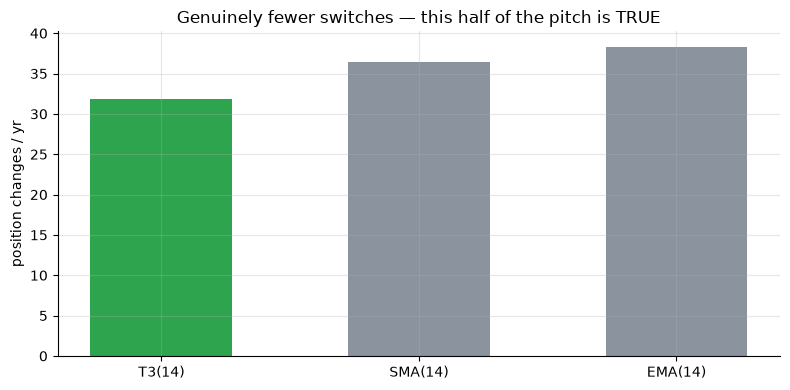

T3 31.9/yr  vs  SMA 36.5/yr  vs  EMA 38.3/yr


In [3]:
if HAVE_REAL:
    r = st.run_experiment(tape('SPY'), t3_n=T3_N, t3_v=T3_V, sma_period=T3_N,
                          ema_period=T3_N, cost_bps=5.0)
    sw = {k: r[k]['switches_per_yr'] for k in ('T3','SMA','EMA')}
else:
    sw = dict(T3=31.9, SMA=36.5, EMA=38.3)
fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.bar(['T3(14)','SMA(14)','EMA(14)'], [sw['T3'],sw['SMA'],sw['EMA']],
       color=[GREEN, GREY, GREY], width=.55)
ax.set_ylabel('position changes / yr')
ax.set_title('Genuinely fewer switches — this half of the pitch is TRUE')
plt.tight_layout(); plt.show()
print(f"T3 {sw['T3']:.1f}/yr  vs  SMA {sw['SMA']:.1f}/yr  vs  EMA {sw['EMA']:.1f}/yr")

**31.9 switches/yr** for T3 against **36.5** for the SMA and **38.3** for the EMA — T3 really is calmer. This part of the claim holds up, and it holds on every ticker in the basket.

**So — does a smoother, if slower, line at least beat holding?**

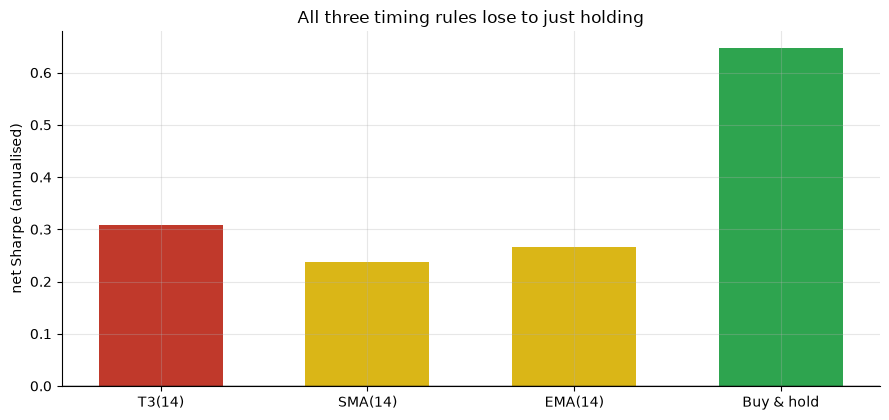

T3 0.308 | SMA 0.238 | EMA 0.267 | hold 0.647


In [4]:
if HAVE_REAL:
    sh = {k: r[k]['sharpe_net'] for k in ('T3','SMA','EMA')}
    sh['B&H'] = r['T3']['bh_sharpe']
else:
    sh = dict(T3=0.308, SMA=0.238, EMA=0.267)
    sh['B&H'] = 0.647
labels = ['T3(14)','SMA(14)','EMA(14)','Buy & hold']
vals = [sh['T3'], sh['SMA'], sh['EMA'], sh['B&H']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(labels, vals, color=[RED, AMBER, AMBER, GREEN], width=.6)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('net Sharpe (annualised)')
ax.set_title('All three timing rules lose to just holding')
plt.tight_layout(); plt.show()
print(f"T3 {sh['T3']:.3f} | SMA {sh['SMA']:.3f} | EMA {sh['EMA']:.3f} | hold {sh['B&H']:.3f}")

Buy-and-hold (Sharpe **0.647**) beats every timing rule; T3's quieter line (**0.308**) is a bit better than the SMA (**0.238**) but nowhere close to just holding. Fewer whipsaws reduced the *damage* of timing — it didn't turn it into an edge.

**Last check — is the timing even real, or is it noise?** Shuffle T3's own calls in time and see if the real ones beat the shuffles.

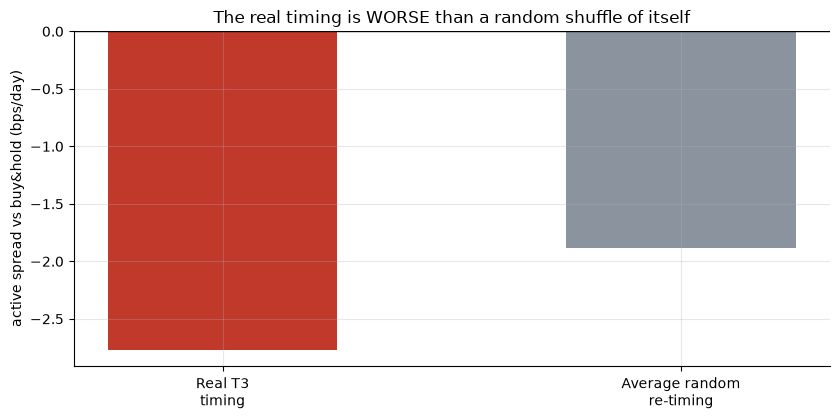

real -2.77 bps/day | random -1.89 bps/day | p = 0.927


In [5]:
if HAVE_REAL:
    p = r['T3_permutation']
    obs, plac, pv = p['observed_spread_bps'], p['placebo_mean_bps'], p['p_value']
else:
    obs, plac, pv = -2.77, -1.89, 0.927
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['Real T3\ntiming', 'Average random\nre-timing'], [obs, plac],
       color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('active spread vs buy&hold (bps/day)')
ax.set_title('The real timing is WORSE than a random shuffle of itself')
plt.tight_layout(); plt.show()
print(f'real {obs:+.2f} bps/day | random {plac:+.2f} bps/day | p = {pv:.3f}')

The real T3 timing (**-2.77 bps/day**) is *worse* than the average random re-timing (**-1.89 bps/day**), and **92.7%** of shuffles beat it. Whatever information T3's crossovers carry, it points the wrong way more often than chance.

## 5 · The verdict

- **Signal — None.** Active spread vs holding **-3.4 bps/day**, *t* = **-4.03** — significantly negative on SPY, on 4 of 5 basket tapes individually, in both sample halves, and at every volume factor v from 0.1 to 0.9. Permutation *p* = 0.927.
- **Tradability — Mirage.** Net Sharpe **0.308** vs buy-and-hold **0.647**; loses even gross, and no cost level rescues it.
- **"Lower-lag, cleaner crossovers"? — Mixed.** Cleaner: **true** (31.9 vs 36.5/38.3 switches/yr). Lower-lag: **false** (slowest of the three to catch a step). Neither half beats the plain MAs T3 claims to improve on.

## 6 · Could you actually trade it?

No. The gross timing already loses to holding; costs only widen the gap. There's no break-even cost because the line starts below zero:

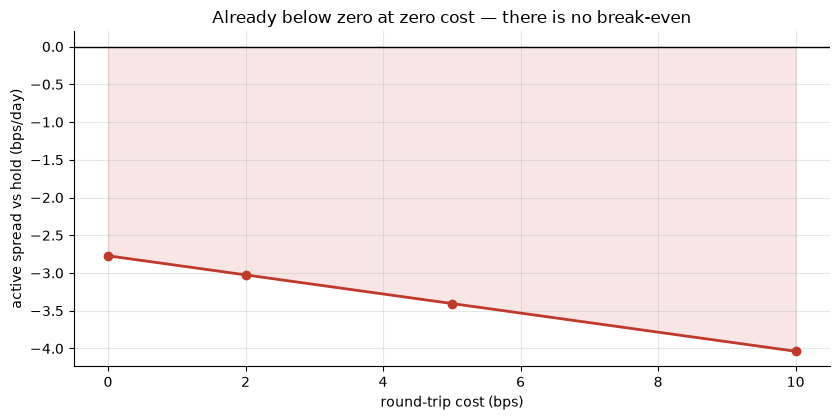

The gross spread is negative; costs are not the issue, the timing is.


In [6]:
if HAVE_REAL:
    costs = [0.0, 2.0, 5.0, 10.0]
    spr = [st.run_experiment(tape('SPY'), t3_n=T3_N, t3_v=T3_V, cost_bps=c)['T3']['mean_spread_bps'] for c in costs]
else:
    costs = [0.0, 2.0, 5.0, 10.0]; spr = [-2.77, -3.02, -3.4, -4.04]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, spr, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, spr, 0, color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('active spread vs hold (bps/day)')
ax.set_title('Already below zero at zero cost — there is no break-even')
plt.tight_layout(); plt.show()
print('The gross spread is negative; costs are not the issue, the timing is.')

## 7 · Going further

- **The positive control.** The companion notebook plants a real trend in a synthetic tape — and the *same* T3 engine catches it cleanly (*t* up to +21). The harness works; the daily stock market just doesn't hand a six-times-smoothed line enough persistent trend to pay for its lag.
- **Shorter periods.** Tillson's own writeups sometimes use N in the 5-8 range to compensate for the six-stage smoothing — worth a fork to see if a shorter T3 closes the lag gap against the SMA/EMA benchmarks.
- **Other 'smarter MA' claims, other fates.** [Study 432 (Hull MA)](../../432-hull-moving-average/) shows the *opposite* failure mode — genuinely less lag, but *more* whipsaws. [Study 672 (McGinley Dynamic)](../../672-mcginley-dynamic/) tests a recursive self-adjusting line on the same infrastructure.

*Think T3 earns its keep at a different N, v, or timeframe? Fork this, and show an active spread that clears HAC *t* = 2 against buy-and-hold. That's the bar.*